Notebook to reproduce the analysis reported in "Outliers Exclusion Procedures Must be Blind to the Researcher’s Hypothesis."

# Preamble

## Imports

In [1]:
import multiprocessing
from functools import partial

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import HTML, display
from joblib import Parallel, delayed
from statsmodels.stats.outliers_influence import OLSInfluence
from tqdm import tqdm

## Functions

In [2]:
# Misc Functions
def welsch_pval(x, y):
    """
    Return the p-value of a Welsch t-test of the difference between two vectors x and y. 
    """
    return stats.ttest_ind(x, y, equal_var=False).pvalue


def mw_pval(x, y):
    """
    Return the p-value of a Mann-Whitney test of the difference between two vectors x and y. 
    """
    return stats.mannwhitneyu(x, y, alternative="two-sided").pvalue


def ks_pval(x, y):
    """
    Return the p-value of a Kolmogorov-Smirnov test of the difference between two vectors x and y.
    """
    return stats.ks_2samp(x, y, alternative="two-sided").pvalue


def mixturesampler(size):
    """
    Return a mixture of two normal distribution: The value is sampled from N(0, 1) with p = .95,
    and with N(5, 1) with p= .05, such that 5% of observations are outliers.
    """
    low = np.random.normal(0, 1, size)
    high = np.random.normal(5, 1, size)
    mixture = np.random.choice([0, 1], p=[0.95, 0.05], size=size)
    return low + high * mixture


def categoricalsampler(size):
    """
    Return a dummy variable vector of size N
    """
    return np.repeat([-1, 1], int(size / 2))


# Functions to remove outliers in discrete cell designs
def remove_outliers(x, cutoff_type="IQR", cutoff_thresh=2):
    """
    Exclude outliers from a vector.
    """
    x = x.copy()
    if cutoff_type == "IQR":
        iqr = stats.iqr(x)
        low = np.percentile(x, 25) - cutoff_thresh * iqr
        high = np.percentile(x, 75) + cutoff_thresh * iqr
        return x[(x >= low) & (x <= high)]
    elif cutoff_type == "z-score":
        sd = np.std(x)
        low = np.mean(x) - cutoff_thresh * sd
        high = np.mean(x) + cutoff_thresh * sd
        return x[(x >= low) & (x <= high)]
    elif cutoff_type == "MAD":
        mad = stats.median_abs_deviation(x, scale="normal")
        med = np.median(x)
        low = med - cutoff_thresh * mad
        high = med + cutoff_thresh * mad
        return x[(x >= low) & (x <= high)]
    elif cutoff_type == "WINS":
        sd = np.std(x)
        low = np.mean(x) - cutoff_thresh * sd
        high = np.mean(x) + cutoff_thresh * sd
        x[x <= low] = low
        x[x >= high] = high
        return x
    else:
        raise ValueError(
            f"Cutoff type {cutoff_type} not understood. Must be 'IQR' or 'SD'"
        )


def remove_outliers_common(x, y, cutoff_type="IQR", cutoff_thresh=2):
    """
    Exclude outliers from two vectors, using the same cutoff for both.
    """
    xy = np.concatenate([x, y])
    x = x.copy()
    y = y.copy()
    if cutoff_type == "IQR":
        iqr = stats.iqr(xy)
        low = np.percentile(xy, 25) - cutoff_thresh * iqr
        high = np.percentile(xy, 75) + cutoff_thresh * iqr
        return (
            x[(x >= low) & (x <= high)],
            y[(y >= low) & (y <= high)],
        )

    elif cutoff_type == "z-score":
        sd = np.std(xy)
        low = np.mean(xy) - cutoff_thresh * sd
        high = np.mean(xy) + cutoff_thresh * sd
        return (
            x[(x >= low) & (x <= high)],
            y[(y >= low) & (y <= high)],
        )

    elif cutoff_type == "MAD":
        mad = stats.median_abs_deviation(x, scale="normal")
        med = np.median(x)
        low = med - cutoff_thresh * mad
        high = med + cutoff_thresh * mad
        return (
            x[(x >= low) & (x <= high)],
            y[(y >= low) & (y <= high)],
        )

    elif cutoff_type == "WINS":
        sd = np.std(xy)
        low = np.mean(xy) - cutoff_thresh * sd
        high = np.mean(xy) + cutoff_thresh * sd
        x[x <= low] = low
        x[x >= high] = high
        y[y <= low] = low
        y[y >= high] = high
        return x, y
    else:
        raise ValueError(
            f"Cutoff type {cutoff_type} not understood. Must be 'IQR' or 'SD'"
        )


def remove_outliers_iter(x, cutoff_type="IQR", cutoff_thresh=2):
    """
    Iteratively exclude outliers from two vectors until none are found.
    """
    x = x.copy()
    if cutoff_type != "WINS":
        x_before = x
        while True:
            x_after = remove_outliers(x_before, cutoff_type, cutoff_thresh)
            if x_before.shape[0] == x_after.shape[0]:
                return x_after
            else:
                x_before = x_after
    else:
        x_before = x
        while True:
            x_after = remove_outliers(x_before, cutoff_type, cutoff_thresh)
            if (x_before == x_after).mean() == 1:
                return x_after
            else:
                x_before = x_after


# Functions to remove residual-based outliers
def remove_residuals_blind(y, X, cutoff_thresh=2):
    """
    Remove outliers from residuals of model that is blind to the key predictor X.
    """
    model = sm.OLS(y, X[:, 1:])
    results = model.fit()
    resids = OLSInfluence(results).resid_studentized_internal
    return (
        y[(resids >= -cutoff_thresh) & (resids <= cutoff_thresh)],
        X[(resids >= -cutoff_thresh) & (resids <= cutoff_thresh), :],
    )


def remove_residuals_aware(y, X, cutoff_thresh=2):
    """
    Remove outliers from residuals of model that is aware of the key predictor X.
    """
    model = sm.OLS(y, X)
    results = model.fit()
    resids = OLSInfluence(results).resid_studentized_internal
    return (
        y[(resids >= -cutoff_thresh) & (resids <= cutoff_thresh)],
        X[(resids >= -cutoff_thresh) & (resids <= cutoff_thresh), :],
    )


# Functions comparing results under different exclusion strategies
def compare_pvals_under_exclusions(x, y, cutoff_type="IQR", cutoff_thresh=2, test=None):
    """
    Compare two vectors of data and return the p-values when (1) No outliers are excluded, (2) Outliers
    are excluded based on a common cutoff, (3) Outliers are excluded using
    a condition-specific cutoff, and (4) Outliers are recursively excluded.
    """
    p = test(x, y)

    x_common, y_common = remove_outliers_common(x, y, cutoff_type, cutoff_thresh)
    p_common = test(x_common, y_common)

    x_diff = remove_outliers(x, cutoff_type, cutoff_thresh)
    y_diff = remove_outliers(y, cutoff_type, cutoff_thresh)
    p_diff = test(x_diff, y_diff)

    x_diff_iter = remove_outliers_iter(x, cutoff_type, cutoff_thresh)
    y_diff_iter = remove_outliers_iter(y, cutoff_type, cutoff_thresh)
    p_diff_iter = test(x_diff_iter, y_diff_iter)
    return [p, p_common, p_diff, p_diff_iter]


def compare_tstats_under_exclusions(x, y, cutoff_type="IQR", cutoff_thresh=2):
    """
    Compare two vectors of data and return the t-stats when (1) Outliers
    are excluded based on a common cutoff or (2) Outliers are excluded using
    a condition-specific cutoff
    """
    x_common, y_common = remove_outliers_common(x, y, cutoff_type, cutoff_thresh)
    diff_common = stats.ttest_ind(x_common, y_common).statistic

    x_diff = remove_outliers(x, cutoff_type, cutoff_thresh)
    y_diff = remove_outliers(y, cutoff_type, cutoff_thresh)
    diff_diff = stats.ttest_ind(x_diff, y_diff).statistic
    return [diff_common, diff_diff]


def compare_pvals_under_resid_exclusions(y, X, cutoff_thresh=2):
    """
    Compare p-values from OLS model when (1) No outliers are excluded, (2) Outliers
    are excluded based the hypothesis-blind residuals,
    (3) Outliers excluded based the hypothesis-aware residuals
    """
    y_blind, X_blind = remove_residuals_blind(y, X, cutoff_thresh=cutoff_thresh)
    y_aware, X_aware = remove_residuals_aware(y, X, cutoff_thresh=cutoff_thresh)
    pvals_base = sm.OLS(y, X).fit().pvalues[0]
    pvals_blind = sm.OLS(y_blind, X_blind).fit().pvalues[0]
    pvals_aware = sm.OLS(y_aware, X_aware).fit().pvalues[0]
    return pvals_base, pvals_blind, pvals_aware


# Functions simulating exclusion impacts in discrete designs.
def simulate_exclusion_impact(n_boots, seed=2743892347):
    """
    Simulate the impact of exclusions based on descriptive statistics 
    in all the different experimental setups.
    """

    # Seed for reproducibility
    np.random.seed(seed)

    # Three data samplers
    data_samplers = [np.random.normal, np.random.lognormal, mixturesampler]
    dic_samplers = {0: "Normal", 1: "Log-Normal", 2: "Normal Mixture"}

    # Three different sample sizes
    sample_sizes = [50, 100, 250]
    dic_ssizes = {0: 50, 1: 100, 2: 250}

    # Three different tests
    tests = [welsch_pval, mw_pval, ks_pval]
    dic_testtypes = {0: "Welsch's t", 1: "Mann-Whitney", 2: "K-S"}

    # Three cutoff types:
    cuttypes = ["IQR", "z-score", "MAD"]
    cuttypes_labels = ["IQR Distance", "z-score", "MAD"]
    dic_cuttypes = {i: c for i, c in enumerate(cuttypes_labels)}

    # Three different exclusion thresholds
    cutthreshs = [1.5, 2, 3]
    dic_cutthreshs = {i: c for i, c in enumerate(cutthreshs)}

    # Four outliers exclusion strategy
    dic_exclutypes = {
        0: "None",
        1: "Across",
        2: "Within",
        3: "Within, Iterated",
    }

    def gen_data_and_get_pvals(seed):
        """
        A function that will be parallelized for faster results.
        """
        np.random.seed(seed)
        data_samplers = [np.random.normal, np.random.lognormal, mixturesampler]
        pvs = np.empty(shape=(3, 3, 3, 3, 3, 4))  # Empty array to store the p-values
        for j, samp in enumerate(data_samplers):  # For each data type
            for k, n in enumerate(sample_sizes):  # For each sample size
                x, y = samp(size=(2, n))  # Draw two vectors from the data
                for l, test in enumerate(tests):  # For each of the tests
                    for m, cuttype in enumerate(
                        cuttypes
                    ):  # For each of the cutoff types
                        for n, cutthresh in enumerate(
                            cutthreshs
                        ):  # For each of the cutoff thresholds
                            p = compare_pvals_under_exclusions(
                                x,
                                y,
                                test=test,
                                cutoff_type=cuttype,
                                cutoff_thresh=cutthresh,
                            )
                            pvs[j, k, l, m, n, :] = p
        return pvs

    seeds = np.random.randint(
        0, 2147483647, size=n_boots
    )  # Seeds sent to parallelized functions
    num_cores = multiprocessing.cpu_count()  # Number of cores
    # Parallelize bootstrap across cores
    results = Parallel(n_jobs=num_cores)(
        delayed(gen_data_and_get_pvals)(s) for s in tqdm(seeds)
    )
    pvals = np.array(results)
    # Reshape the results into a square matrix
    cols = np.column_stack(
        list(map(np.ravel, np.meshgrid(*map(np.arange, pvals.shape), indexing="ij")))
        + [pvals.ravel()]
    )
    # Store into a dataframe
    df_pvals = pd.DataFrame(
        cols,
        columns=[
            "nboot",
            "Data",
            "N",
            "Test",
            "Method",
            "Threshold",
            "Level",
            "pvalue",
        ],
    )
    # Add descriptive labels to each of the setups
    df_pvals["Data"] = df_pvals.Data.map(dic_samplers)
    df_pvals["N"] = df_pvals.N.map(dic_ssizes)
    df_pvals["Test"] = df_pvals.Test.map(dic_testtypes)
    df_pvals["Method"] = df_pvals.Method.map(dic_cuttypes)
    df_pvals["Threshold"] = df_pvals.Threshold.map(dic_cutthreshs)
    df_pvals["Level"] = pd.Categorical(
        df_pvals.Level.map(dic_exclutypes),
        categories=["None", "Across", "Within", "Within, Iterated"],
    )
    # Compute Type I error rates for different alphas
    df_pvals["$\\alpha_{{05}}$"] = (df_pvals.pvalue < 0.05) * 1
    df_pvals["$\\alpha_{{01}}$"] = (df_pvals.pvalue < 0.01) * 1
    df_pvals["$\\alpha_{{001}}$"] = (df_pvals.pvalue < 0.001) * 1
    return df_pvals


def simulate_resid_exclusion_impact(n_boots, seed=2743892347):
    """
    Simulate the impact of exclusions based on residuals 
    in all the different experimental setups.
    """

    # Seed for reproducibility
    np.random.seed(seed)

    # Three data samplers for IV
    DV_samplers = [np.random.normal, np.random.lognormal, mixturesampler]
    dic_DV_samplers = {0: "Normal", 1: "Log-Normal", 2: "Normal Mixture"}

    # Two data samplers for IV
    IV_samplers = [np.random.normal, categoricalsampler]
    dic_IV_samplers = {0: "Continuous", 1: "Categorical"}

    # Three different sample sizes
    sample_sizes = [50, 100, 240]
    dic_ssizes = {0: 50, 1: 100, 2: 240}

    # Four outliers exclusion strategy
    dic_exclutypes = {0: "None", 1: "Predictor-Blind", 2: "Predictor-Aware"}

    def gen_data_and_get_pvals(seed):
        """
        A function that will be parallelized for faster results.
        """
        np.random.seed(seed)
        DV_samplers = [np.random.normal, np.random.lognormal, mixturesampler]
        IV_samplers = [np.random.normal, categoricalsampler]
        # Empty array to store the p-values
        pvals = np.empty(shape=(3, 2, 3, 3))
        for j, dvsamp in enumerate(DV_samplers):  # For each DV type
            for k, ivsamp in enumerate(IV_samplers):  # For each IV type
                for l, n in enumerate(sample_sizes):  # For each sample size
                    intercept = np.ones(n)
                    w = np.random.normal(size=n)  # Vector of covariates
                    y = dvsamp(size=n) + w  # Vector of DV, influenced by covariates
                    x = ivsamp(size=n)  # Vector of IV, that has no influence on Y.
                    X = np.vstack([x, intercept, w]).T
                    pvals[j, k, l, :] = compare_pvals_under_resid_exclusions(y, X)
        return pvals

    seeds = np.random.randint(
        0, 2147483647, size=n_boots
    )  # Seeds sent to parallelized functions
    num_cores = multiprocessing.cpu_count()  # Number of cores
    # Parallelize bootstrap across cores
    results = Parallel(n_jobs=num_cores)(
        delayed(gen_data_and_get_pvals)(s) for s in tqdm(seeds)
    )
    pvals = np.array(results)

    # Reshape the results into a square matrix
    cols = np.column_stack(
        list(map(np.ravel, np.meshgrid(*map(np.arange, pvals.shape), indexing="ij")))
        + [pvals.ravel()]
    )
    # Store into a dataframe
    df_pvals = pd.DataFrame(
        cols, columns=["nboot", "DVType", "IVType", "N", "Level", "pvalue",],
    )
    # Add descriptive labels to each of the setups
    df_pvals["DVType"] = df_pvals.DVType.map(dic_DV_samplers)
    df_pvals["IVType"] = df_pvals.IVType.map(dic_IV_samplers)
    df_pvals["N"] = df_pvals.N.map(dic_ssizes)
    df_pvals["Level"] = pd.Categorical(
        df_pvals.Level.map(dic_exclutypes),
        categories=["None", "Predictor-Blind", "Predictor-Aware"],
    )
    # Compute Type I error rates for different alphas
    df_pvals["$\\alpha_{{05}}$"] = (df_pvals.pvalue < 0.05) * 1
    df_pvals["$\\alpha_{{01}}$"] = (df_pvals.pvalue < 0.01) * 1
    df_pvals["$\\alpha_{{001}}$"] = (df_pvals.pvalue < 0.001) * 1
    return df_pvals


# Functions to simulate exclusion impacts in real data
def simulate_exclusion_impact_ckg(df, n_boots, n=31, seed=2743892347):
    """
    Simulate the exclusion impacts in Cao, Kong, and Galinsky's original data.
    This function shuffles the residuals of the model on the full data (before exclusions)
    to create a synthetic dataset, and compares two random groups of size N draw from this data.
    N = 31 for Study 2, and 37 for Study 1.
    """
    # Predicted values before excluding participants.
    predicted = smf.ols("ParetoEfficiency~C(Condition)", data=df).fit().predict()

    # Residuals
    resids = (df.ParetoEfficiency - predicted).values

    # Seed for reproducibility
    np.random.seed(seed)  # Seed for reproducibility

    # Three cutoff types:
    cuttypes = ["IQR", "z-score", "MAD"]
    cuttypes_labels = ["IQR Distance", "z-score", "MAD"]
    dic_cuttypes = {i: c for i, c in enumerate(cuttypes_labels)}

    # Three different exclusion thresholds
    cutthreshs = [1.5, 2, 3]
    dic_cutthreshs = {i: c for i, c in enumerate(cutthreshs)}

    # Four different exclusion types
    dic_exclutypes = {
        0: "None",
        1: "Across",
        2: "Within",
        3: "Within, Iterated",
    }

    def gen_data_and_get_pvals(seed):
        """
        A function that will be parallelized for faster results.
        """
        np.random.seed(seed)
        # Empty array to store the p-values
        pvals = np.empty(shape=(3, 3, 4))
        np.random.shuffle(resids)  # Shuffle the residuals
        data = (
            predicted + resids
        )  # Add residuals to predicted values to generate synthetic data
        xy = np.random.choice(
            data, n * 2, replace=False
        )  # Draw a random sample from the data
        x, y = xy[:n], xy[n:]  # Split them in two "conditions"
        for j, cuttype in enumerate(cuttypes):  # For each cutoff type
            for k, cutthresh in enumerate(cutthreshs):  # For each threshold
                pvals[
                    j, k, :
                ] = compare_pvals_under_exclusions(  # Compare p-values under different exclusions
                    x,
                    y,
                    cutoff_thresh=cutthresh,
                    cutoff_type=cuttype,
                    test=welsch_pval,
                )
        return pvals

    seeds = np.random.randint(
        0, 2147483647, size=n_boots
    )  # Seeds sent to parallelized functions

    num_cores = multiprocessing.cpu_count()  # Number of cores
    # Parallelize bootstrap across cores
    results = Parallel(n_jobs=num_cores)(
        delayed(gen_data_and_get_pvals)(s) for s in tqdm(seeds)
    )
    pvals = np.array(results)

    # Reshape the results into a square matrix
    cols = np.column_stack(
        list(map(np.ravel, np.meshgrid(*map(np.arange, pvals.shape), indexing="ij")))
        + [pvals.ravel()]
    )

    # Store the matrix as a dataframe
    df_pvals = pd.DataFrame(
        cols, columns=["nboot", "Method", "Threshold", "Level", "pvalue"],
    )

    # Add descriptive labels
    df_pvals["Method"] = df_pvals.Method.map(dic_cuttypes)
    df_pvals["Threshold"] = df_pvals.Threshold.map(dic_cutthreshs)
    df_pvals["Level"] = pd.Categorical(
        df_pvals.Level.map(dic_exclutypes),
        categories=["None", "Across", "Within", "Within, Iterated"],
    )

    # Compute Type I error rates for different alphas
    df_pvals["$\\alpha_{{05}}$"] = (df_pvals.pvalue < 0.05) * 1
    df_pvals["$\\alpha_{{01}}$"] = (df_pvals.pvalue < 0.01) * 1
    df_pvals["$\\alpha_{{001}}$"] = (df_pvals.pvalue < 0.001) * 1
    return df_pvals


# Plotting functions
def hist_no_edge(x, *args, **kwargs):
    """
    Plot a histogram without the left and right edges. Useful for survival curves.
    """
    bins = kwargs.pop("bins")
    cumulative = kwargs.pop("cumulative", False)
    # Add a bin for all p-values between the upper bin and 1.
    cnt, edges = np.histogram(x, bins=bins.tolist() + [1])
    ax = plt.gca()
    if cumulative:
        prop = cnt.cumsum() / cnt.sum()
        ax.step(edges[:-2], prop[:-1], *args, **kwargs)
    else:
        ax.step(edges[:-2], cnt, *args, **kwargs)


def plot_simulation_results(data, include_iterated=True):
    """
    Plot the survival curve of all the simulations. 
    """
    gb = data.groupby(["Threshold", "Method", "Level"])  # Data by group.

    # Type I error at various alpha levels
    p_05 = gb["$\\alpha_{{05}}$"].mean()
    p_01 = gb["$\\alpha_{{01}}$"].mean()
    p_001 = gb["$\\alpha_{{001}}$"].mean()

    # Labels for lines and panels
    thresholds = [1.5, 2.0, 3.0]
    methods = ["IQR Distance", "z-score", "MAD"]
    if include_iterated:
        levels = ["None", "Across", "Within", "Within, Iterated"]
        labels = ["None", "Across", "Within", "Within, Iter."]
        maxcoord = 4
    else:
        levels = ["None", "Across", "Within"]
        labels = ["None", "Across", "Within"]
        data = data.query("Level != 'Within, Iterated'")
        maxcoord = 3

    ycoords = 0.65 + np.arange(0, 1, 0.06)  # Coordinates to plot legend

    pal = sns.color_palette()[0:4]  # Colors

    # Initialize the plot
    g = sns.FacetGrid(
        data,
        col="Threshold",
        row="Method",
        hue="Level",
        hue_order=levels,
        col_order=thresholds,
        row_order=methods,
        height=3.4,
        aspect=1.2,
        sharey=True,
        sharex=True,
        hue_kws=dict(ls=[(0, ()), (1, (5, 5)), (0, ()), (1, ())]),
    )

    # Map the survival curve to each panel and color
    g.map(
        hist_no_edge,
        "pvalue",
        cumulative=True,
        bins=np.logspace(np.log10(10e-40), np.log10(0.05), 10000),
        lw=1.5,
    )

    # Change the axes labels
    g.set_ylabels("Fraction of Sig. Tests ($p < \\alpha$)")
    g.set_xlabels("Sig. Threshold ($\\alpha$)")
    g.set_titles("Cutoff: {col_name} * {row_name}")

    # Adjust the axes and ticks
    for i, (axe, meth) in enumerate(zip(g.axes, methods)):
        for j, (ax, thresh) in enumerate(zip(axe, thresholds)):
            ax.set_xlim(10e-8, 0.05)
            ax.set_xscale("log")
            ax.set_xticks([10e-8, 10e-7, 10e-6, 10e-5, 10e-4, 10e-3, 0.05])
            ax.set_xticklabels(
                ["10e-8", "10e-7", ".00001", ".0001", ".001", ".01", ".05"]
            )
            ax.set_xticks([], minor=True)
            ax.invert_xaxis()
            ax.annotate(
                f"Type I Error Rate at $[\\alpha_{{05}}, \\alpha_{{01}}, \\alpha_{{001}}]$",
                (1, ycoords[maxcoord]),
                color="black",
                fontsize=10,
                ha="right",
                xycoords="axes fraction",
            )
            _, yh = ax.get_ylim()
            ys = np.round(yh / 6, 2)
            ax.set_yticks(np.arange(0, yh, ys))
            # Add the false-positive annotations
            for k, (lab, lev) in enumerate(zip(labels, levels)):
                ax.annotate(
                    f"{lab}: [{p_05.loc[thresh, meth, lev]:.2f}, "
                    f" {p_01.loc[thresh, meth, lev]:.2f}, "
                    f"{p_001.loc[thresh, meth, lev]:.3f}]",
                    (1, ycoords[k]),
                    color=pal[k],
                    ha="right",
                    xycoords="axes fraction",
                    fontsize=10,
                )


def plot_resids_simulation_results(data, include_iterated=True):
    """
    Plot the survival curve of all the simulations. 
    """
    gb = data.groupby(["DVType", "IVType", "Level"])  # Data by group.

    # Type I error at various alpha levels
    p_05 = gb["$\\alpha_{{05}}$"].mean()
    p_01 = gb["$\\alpha_{{01}}$"].mean()
    p_001 = gb["$\\alpha_{{001}}$"].mean()

    # Labels for lines and panels
    dvtype_labels = ["Normal", "Log-Normal", "Normal Mixture"]
    ivtype_labels = ["Continuous", "Categorical"]

    levels = ["None", "Predictor-Blind", "Predictor-Aware"]
    labels = ["None", "Predictor-Blind", "Predictor-Aware"]
    maxcoord = 3

    ycoords = 0.65 + np.arange(0, 1, 0.06)  # Coordinates to plot legend

    pal = sns.color_palette()[0:4]  # Colors

    # Initialize the plot
    g = sns.FacetGrid(
        data,
        col="DVType",
        row="IVType",
        hue="Level",
        hue_order=levels,
        col_order=dvtype_labels,
        row_order=ivtype_labels,
        height=3.4,
        aspect=1.2,
        sharey=True,
        sharex=True,
        hue_kws=dict(ls=[(0, ()), (1, (5, 5)), (0, ()), (1, ())]),
    )

    # Map the survival curve to each panel and color
    g.map(
        hist_no_edge,
        "pvalue",
        cumulative=True,
        bins=np.logspace(np.log10(10e-40), np.log10(0.05), 10000),
        lw=1.5,
    )

    # Change the axes labels
    g.set_ylabels("Fraction of Sig. Tests ($p < \\alpha$)")
    g.set_xlabels("Sig. Threshold ($\\alpha$)")
    g.set_titles("{col_name} Data, {row_name} IV")

    # Adjust the axes and ticks
    for i, (axe, ivtyp) in enumerate(zip(g.axes, ivtype_labels)):
        for j, (ax, dvtyp) in enumerate(zip(axe, dvtype_labels)):
            ax.set_xlim(10e-8, 0.05)
            ax.set_xscale("log")
            ax.set_xticks([10e-8, 10e-7, 10e-6, 10e-5, 10e-4, 10e-3, 0.05])
            ax.set_xticklabels(
                ["10e-8", "10e-7", ".00001", ".0001", ".001", ".01", ".05"]
            )
            ax.set_xticks([], minor=True)
            ax.invert_xaxis()
            ax.annotate(
                f"Type I Error Rate at $[\\alpha_{{05}}, \\alpha_{{01}}, \\alpha_{{001}}]$",
                (1, ycoords[maxcoord]),
                color="black",
                fontsize=10,
                ha="right",
                xycoords="axes fraction",
            )
            _, yh = ax.get_ylim()
            ys = np.round(yh / 6, 2)
            ax.set_yticks(np.arange(0, yh, ys))
            # Add the false-positive annotations
            for k, (lab, lev) in enumerate(zip(labels, levels)):
                ax.annotate(
                    f"{lab}: [{p_05.loc[dvtyp, ivtyp, lev]:.2f}, "
                    f" {p_01.loc[dvtyp, ivtyp, lev]:.2f}, "
                    f"{p_001.loc[dvtyp, ivtyp, lev]:.3f}]",
                    (1, ycoords[k]),
                    color=pal[k],
                    ha="right",
                    xycoords="axes fraction",
                    fontsize=10,
                )

## Loading Data from Cao, Kong and Galinsky (2020)

In [3]:
def flag_outliers_iqr(x, cutoff_thresh=3):
    """
    Flag the outliers using the IQR method.
    """
    iqr = stats.iqr(x)
    low = np.percentile(x, 25) - cutoff_thresh * iqr
    high = np.percentile(x, 75) + cutoff_thresh * iqr
    return np.array((x <= low) | (x >= high))


def generate_outliers_subsets(df):
    """
    Process the data from Cao, Kong, and Galinsky according to different outliers exclusions:
    * Before Exclusions
    * Exclusions Across Data
    * Exclusions Within Conditions
    * Exclusions Within Conditions, Iterated
    """

    df["Exclusions"] = "None"

    # Flagging outliers within and across conditions
    df["Outliers_within"] = df.groupby("Condition")["ParetoEfficiency"].transform(
        flag_outliers_iqr
    )
    df["Outliers_across"] = flag_outliers_iqr(df["ParetoEfficiency"])

    # Generating different subsets of data:
    ## ...Outliers removed across
    df_oa = df[df.Outliers_across == False].copy()
    df_oa["Exclusions"] = "Across"

    ## ...Outliers removed within
    df_ow = df[df.Outliers_within == False].copy()
    df_ow["Exclusions"] = "Within"
    df_ow["Outliers_within_iter"] = df_ow.groupby("Condition")[
        "ParetoEfficiency"
    ].transform(flag_outliers_iqr)

    ## ...Outliers removed iteratively
    df_owi = df_ow[df_ow.Outliers_within_iter == False].copy()
    df_owi["Exclusions"] = "Within, Iterated"

    # Return the data with the four possible subsets
    return pd.concat([df, df_oa, df_ow, df_owi])


# Study 1 from Cao, Kong and Galinsky
df1 = pd.read_csv("Data/CKG_Study 1.csv")

# Shorter variable names
df1["Outliers"] = (
    df1[
        "Pareto Efficiency Outlier (1=Yes, 0=No) (for Dyad at least one having prior negotiation training)"
    ]
    == "1"
) * 1
df1["ParetoEfficiency"] = df1["Pareto Efficiency"]

# Processing non-outliers exclusions
df1_clean = df1[
    df1[
        "Excluded (dyad at least one having prior negotiation training or violating the protocol) (1 = Yes, 0 = No)"
    ]
    == 0
]

# One data point per dyad
df1_clean = df1_clean.drop_duplicates(subset=["Team ID"])[
    ["Condition", "Outliers", "ParetoEfficiency"]
]

# Generating subsets
df1_subsets = generate_outliers_subsets(df1_clean)
df1_subsets["Study"] = "Study 1"

# Same thing for Study 2
df2 = pd.read_csv("Data/CKG_Study 2.csv")

# Shorter variable names
df2["Outliers"] = (df2["Extreme Outlier (Pareto Efficiency) (1=Yes, 0=No)"] == "1") * 1
df2["ParetoEfficiency"] = df2["Pareto Efficiency"]

# Processing non-outliers exclusions
df2_clean = df2[df2["Exclusion (Both Prior Training and Protocol Violation)"] == 0]

# One data point per dyad
df2_clean = df2_clean.drop_duplicates(subset=["Team ID"])[
    ["Condition", "Outliers", "ParetoEfficiency"]
]

# Generating subsets
df2_subsets = generate_outliers_subsets(df2_clean)
df2_subsets["Study"] = "Study 2"

df_all = pd.concat([df1_subsets, df2_subsets])

# Figures and Results

## Figure 1: Example of a Boxplot

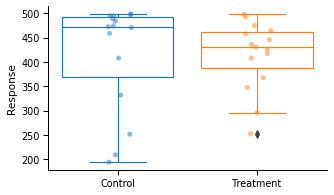

In [4]:
np.random.seed(4278247)  # Seed for reproducibility

# Random data and conditions
x = 500 - np.random.exponential(size=30) * 100
c = np.repeat(["Treatment", "Control"], 15)
df = pd.DataFrame({"Response": x, "Condition": c})

# Boxplot
with sns.plotting_context("paper", font_scale=1.1):
    pal = sns.color_palette()
    fig, ax = plt.subplots(1, figsize=(5, 3))
    sns.boxplot(x="Condition", y="Response", data=df, order=["Control", "Treatment"])

    # Making boxplot transparent
    for i, box in enumerate(ax.artists):
        box.set_edgecolor(pal[i])
        box.set_facecolor("white")
        for j in range(6 * i, 6 * (i + 1)):
            ax.lines[j].set_color(pal[i])

    # Add overlay with observations
    sns.stripplot(
        x="Condition",
        y="Response",
        data=df,
        ax=ax,
        alpha=0.5,
        order=["Control", "Treatment"],
    )
    sns.despine()
    ax.set_xlabel("")
    plt.savefig("Figures/Fig1.png", dpi=200, bbox_inches="tight")

## Figure 2: Visualizing the impact of exclusions within conditions

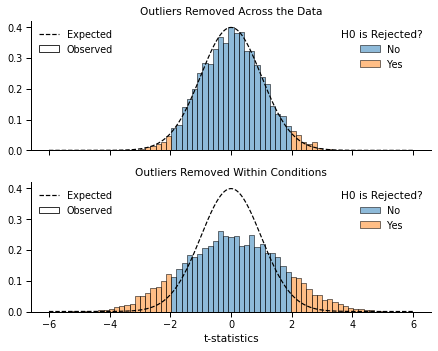

In [5]:
np.random.seed(273984312)  # Seed for reproducibility

# Generate vectors of Student t-statistics for two outliers exclusion strategies: Across vs. Within Conditions.
data = [
    compare_tstats_under_exclusions(
        np.random.lognormal(size=100),
        np.random.lognormal(size=100),
        cutoff_type="IQR",
        cutoff_thresh=1.5,
    )
    for i in range(5000)
]

# Store vectors into a dataframe
df = pd.DataFrame(data, columns=["Across the Data", "Within Conditions"])
df["bootid"] = np.arange(5000)
df_long = pd.melt(
    df, id_vars=["bootid"], value_vars=["Across the Data", "Within Conditions"],
)
df_long["Reject H0"] = (np.abs(df_long.value) > stats.t.ppf(0.975, 198)).map(
    {False: "No", True: "Yes"}
)

# Plot the histogram of the t-statistics
bins = np.linspace(-5.9161, 5.9161, 70)
maxprop = np.diff(stats.t.cdf(bins, 198)).max()
maxp = stats.t.pdf(0, 198)
scaling = 5000 * (maxprop / maxp)
with sns.plotting_context("paper", font_scale=1.1):
    g = sns.FacetGrid(
        row="variable",
        data=df_long,
        aspect=2.5,
        height=2.5,
        hue="Reject H0",
        sharey=True,
    )
    g.map(sns.histplot, "value", bins=bins, alpha=0.5, stat="count", common_norm=True)

    # Add the theoretical Student t-distribution
    for ax in g.axes.flatten():
        ticks = ax.get_yticks()
        ticklabs = np.round(np.linspace(0, 0.4, 5), 2)
        ax.set_yticks(ticklabs * scaling)
        ax.set_yticklabels(ticklabs)
        leg = ax.legend(frameon=False, title="H0 is Rejected?")
        ax.add_artist(leg)
        x = np.linspace(-6, 6, 1000)
        pdf = stats.t.pdf(x, 198)
        ax.plot(x, pdf * scaling, color="black", ls="--")
        (expected,) = plt.plot([], [], color="black", ls="--")
        observed = mpatches.Patch(fc="white", ec="black")
        ax.legend(
            handles=[expected, observed],
            labels=["Expected", "Observed"],
            frameon=False,
            loc=2,
        )

    # Adjust plot
    g.set_xlabels("t-statistics")
    g.set_titles("Outliers Removed {row_name}")
    plt.savefig("Figures/Fig2.png", dpi=200, bbox_inches="tight")

## Figure 3: Understanding the magnifying impact of by-condition exclusions

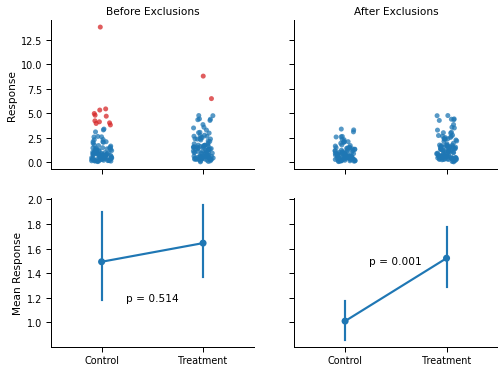

In [6]:
np.random.seed(2389326705)  # Seed for reproducibility

x, y = np.random.lognormal(size=(2, 100))  # Data before exclusions
xt = remove_outliers(x, cutoff_thresh=1.5)  # Data after exclusions
yt = remove_outliers(y, cutoff_thresh=1.5)

# Generating the "before exclusions" dataset, and flagging outliers in it.
resp = x.tolist() + y.tolist()
cond = np.repeat(["Control", "Treatment"], [x.shape[0], y.shape[0]])
df_noexcl = pd.DataFrame(dict(Response=resp, Condition=cond))
df_noexcl["Outliers"] = df_noexcl.groupby("Condition").transform(
    lambda x: flag_outliers_iqr(x, cutoff_thresh=1.5)
)

# Generating the "after exclusions" dataset
resp = xt.tolist() + yt.tolist()
cond = np.repeat(["Control", "Treatment"], [xt.shape[0], yt.shape[0]])
df_excl = pd.DataFrame(dict(Response=resp, Condition=cond))
df_excl["Outliers"] = False
dfs = [df_noexcl, df_excl]

# Plotting the results
pal_rb = sns.color_palette()[0:5:3]
with sns.plotting_context("paper", font_scale=1.1):
    pal = sns.color_palette()
    fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey="row", sharex=True)
    for ax, d in zip(axes[0], dfs):
        sns.stripplot(
            x="Condition",
            y="Response",
            hue="Outliers",
            data=d,
            alpha=0.75,
            jitter=0.1,
            order=["Control", "Treatment"],
            ax=ax,
            palette=pal_rb,
        )
        sns.despine()
        ax.legend([], [], frameon=False)
        ax.set_xlabel("")
        ax.set_ylabel("")
    for ax, d in zip(axes[1], dfs):
        sns.pointplot(
            x="Condition", y="Response", data=d, order=["Control", "Treatment"], ax=ax,
        )
        ax.set_ylabel("")
        ax.set_xlabel("")

    axes[0][0].set_title("Before Exclusions")
    axes[0][1].set_title("After Exclusions")
    axes[0][0].set_ylabel("Response")
    axes[1][0].set_ylabel("Mean Response")

    pval_before = stats.ttest_ind(x, y, equal_var=False).pvalue
    pval_after = stats.ttest_ind(xt, yt, equal_var=False).pvalue
    axes[1][0].annotate(f"p = {pval_before:.3f}", (0.5, 1.2), ha="center", va="center")
    axes[1][1].annotate(f"p = {pval_after:.3f}", (0.5, 1.5), ha="center", va="center")
    plt.savefig("Figures/Fig3.png", dpi=200, bbox_inches="tight")

## Figure 4: Simulations across different setups

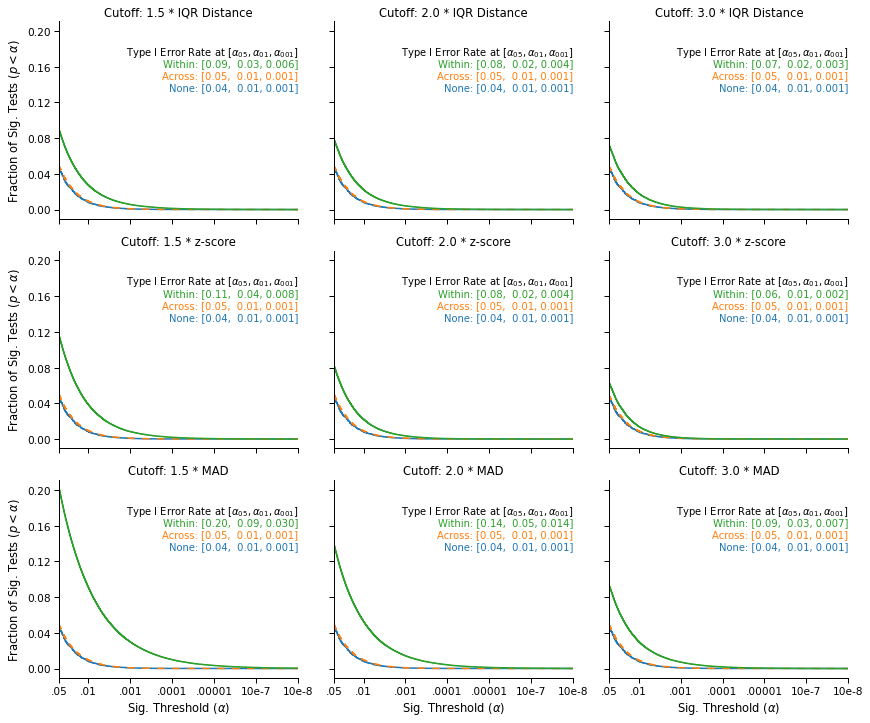

In [7]:
if "df_pvals" not in locals():  # See if the simulations are loaded in memory
    try:  # If not, see if the simulations have been performed yet.
        df_pvals = pd.read_csv("Buffer/Buffered_pvals.csv")
    except:  # Otherwise perform them. Might take up to a few hours.
        df_pvals = simulate_exclusion_impact(20000)
        df_pvals.to_csv("Buffer/Buffered_pvals.csv", index=None)
with sns.plotting_context("paper", font_scale=1.2):
    # Plot the simulation results
    plot_simulation_results(df_pvals, include_iterated=False)
    plt.tight_layout()
    plt.savefig("Figures/Fig4.png", dpi=200, bbox_inches="tight")

### Subset Analysis: Type I Errors when applying a t-test to Log-Normal data

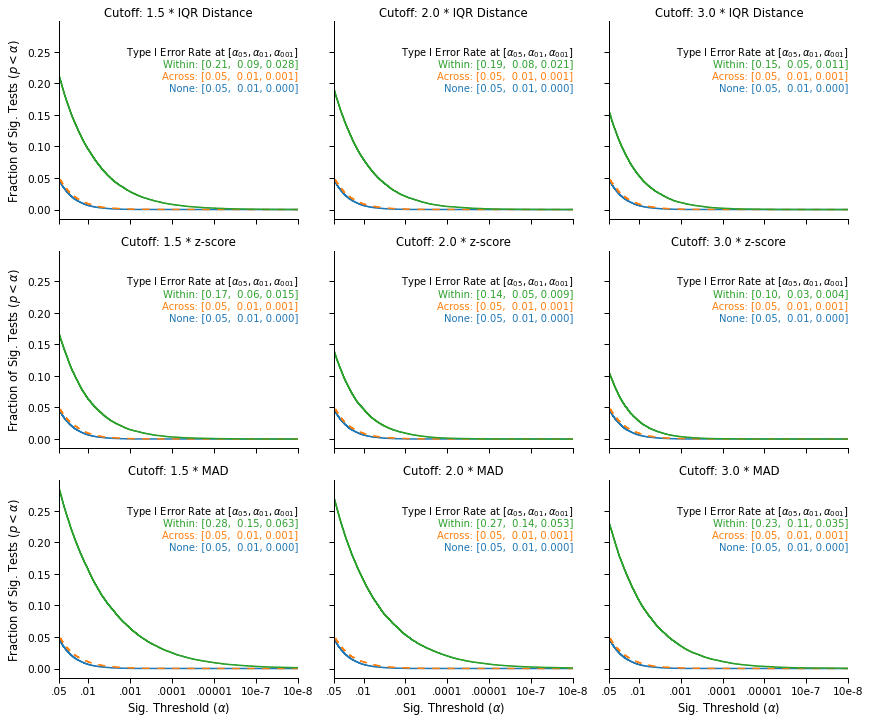

In [8]:
with sns.plotting_context("paper", font_scale=1.2):
    # Plot the simulation results
    plot_simulation_results(
        df_pvals.query("(Data == 'Log-Normal')").query('Test == "Welsch\'s t"'),
        include_iterated=False,
    )
    plt.tight_layout()

### Granular description of Type I Error rates (α = .05) when excluding within conditions (nominal is 5%)

In [9]:
gb = (
    df_pvals.query("Level == 'Within'")
    .groupby(["N", "Data", "Test", "Method", "Threshold"], sort=False)
    .mean()
    .iloc[:, 2]
    .unstack(-2)
    .unstack(-1)
    * 100
)
gb.style.format("{:.0f}%")

### Granular description of Type I Error rates (α = .01) when excluding within conditions (nominal is 10‰)

In [10]:
gb = (
    df_pvals.query("Level == 'Within'")
    .groupby(["N", "Data", "Test", "Method", "Threshold"], sort=False)
    .mean()
    .iloc[:, 3]
    .unstack(-2)
    .unstack(-1)
    * 1000
)
gb.style.format("{:.0f}‰")

### Granular description of Type I Error rates (α = .001) when excluding within conditions (nominal is 1‰)

In [11]:
gb = (
    df_pvals.query("Level == 'Within'")
    .groupby(["N", "Data", "Test", "Method", "Threshold"], sort=False)
    .mean()
    .iloc[:, 4]
    .unstack(-2)
    .unstack(-1)
    * 1000
)
gb.style.format("{:.1f}‰")

## Figure 5: Visualization of Results in Cao, Kong and Galinsky (2020)

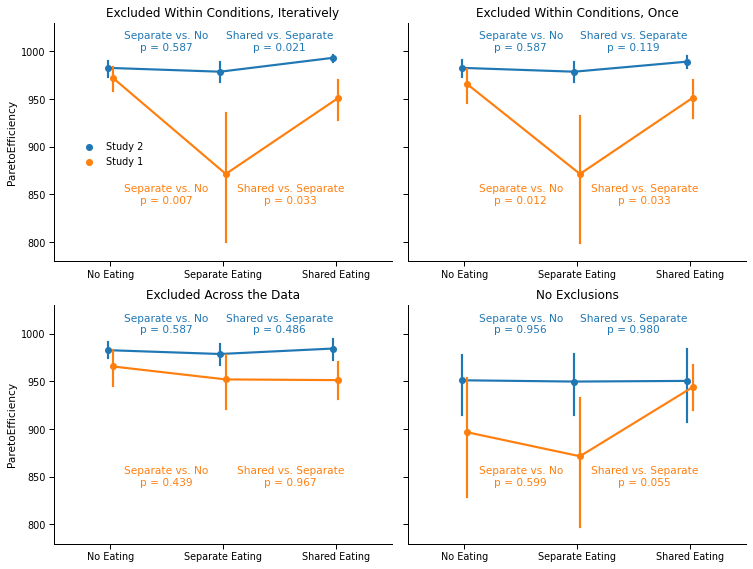

In [12]:
# Summary of means, by condition, study, and exclusion strategy.
with sns.plotting_context("paper", font_scale=1.1):
    g = sns.catplot(
        x="Condition",
        y="ParetoEfficiency",
        col="Exclusions",
        col_wrap=2,
        data=df_all,
        kind="point",
        hue="Study",
        join=True,
        dodge=True,
        aspect=1.3,
        height=4,
        legend=False,
        sharex=False,
        hue_order=["Study 2", "Study 1"],
        order=["No Eating", "Separate Eating", "Shared Eating"],
        col_order=["Within, Iterated", "Within", "Across", "None"],
    )

    # Changing labels
    g.set_titles("Exclusions: {col_name}")
    g.set_xlabels("")

    axes = g.axes.flatten()

    # Adding p-values for study 1
    for excl, ax in zip(["Within, Iterated", "Within", "Across", "None"], axes):
        d = df1_subsets.query("Exclusions == @excl")
        shared = d.query("Condition == 'Shared Eating'").ParetoEfficiency
        sep = d.query("Condition == 'Separate Eating'").ParetoEfficiency
        no = d.query("Condition == 'No Eating'").ParetoEfficiency
        p1 = stats.ttest_ind(sep, no, equal_var=False).pvalue
        p2 = stats.ttest_ind(shared, sep, equal_var=False).pvalue
        ax.annotate(
            f"Separate vs. No\np = {p1:-1.3f}",
            (0.5, 850),
            ha="center",
            va="center",
            color=pal[1],
        )
        ax.annotate(
            f"Shared vs. Separate\np = {p2:.3f}",
            (1.6, 850),
            ha="center",
            va="center",
            color=pal[1],
        )

    # Adding p-values for study 2
    for excl, lab, ax in zip(
        ["Within, Iterated", "Within", "Across", "None"],
        [
            "Excluded Within Conditions, Iteratively",
            "Excluded Within Conditions, Once",
            "Excluded Across the Data",
            "No Exclusions",
        ],
        axes,
    ):
        d = df2_subsets.query("Exclusions == @excl")
        shared = d.query("Condition == 'Shared Eating'").ParetoEfficiency
        sep = d.query("Condition == 'Separate Eating'").ParetoEfficiency
        no = d.query("Condition == 'No Eating'").ParetoEfficiency
        p1 = stats.ttest_ind(sep, no, equal_var=False).pvalue
        p2 = stats.ttest_ind(shared, sep, equal_var=False).pvalue
        ax.set_ylim(780, 1030)
        ax.set_title(lab, size=12)
        ax.annotate(
            f"Separate vs. No\np = {p1:-1.3f}",
            (0.5, 1010),
            ha="center",
            va="center",
            color=pal[0],
        )
        ax.annotate(
            f"Shared vs. Separate\np = {p2:.3f}",
            (1.5, 1010),
            ha="center",
            va="center",
            color=pal[0],
        )
    g.add_legend(title="", loc=(0.1, 0.7))
    plt.savefig("Figures/Fig5.png", dpi=200, bbox_inches="tight")

## Figure 6: Simulating Exclusion Impacts in Cao, Kong and Galinsky (2020)

### In Study 2

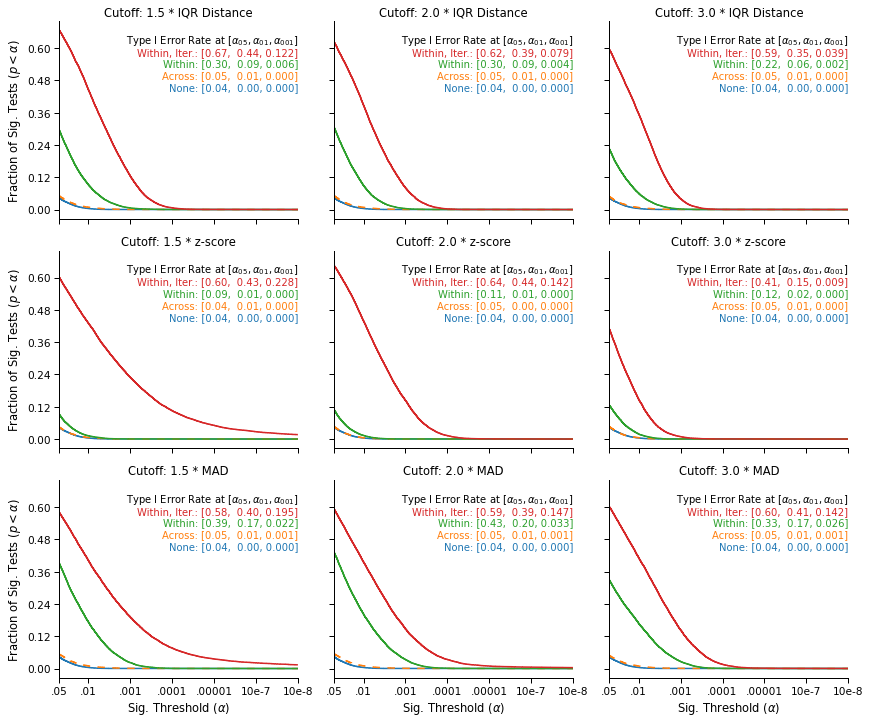

In [13]:
if (
    "df_pvals_ckg_s2" not in locals()
):  # See if the simulations for CKG are loaded in memory
    try:  # If not, see if the simulations have been performed yet.
        df_pvals_ckg_s2 = pd.read_csv("Buffer/Buffered_pvals_ckg_s2.csv")
    except:  # Otherwise perform them.
        df_pvals_ckg_s2 = simulate_exclusion_impact_ckg(
            df2_clean.sort_values("Condition"), 20000, n=31
        )
        df_pvals_ckg_s2.to_csv("Buffer/Buffered_pvals_ckg_s2.csv", index=None)

# Plot the simulation results
with sns.plotting_context("paper", font_scale=1.2):
    plot_simulation_results(df_pvals_ckg_s2, include_iterated=True)
    plt.tight_layout()
    plt.savefig("Figures/Fig6.png", dpi=200, bbox_inches="tight")

### Similar Results are Observed in Study 1

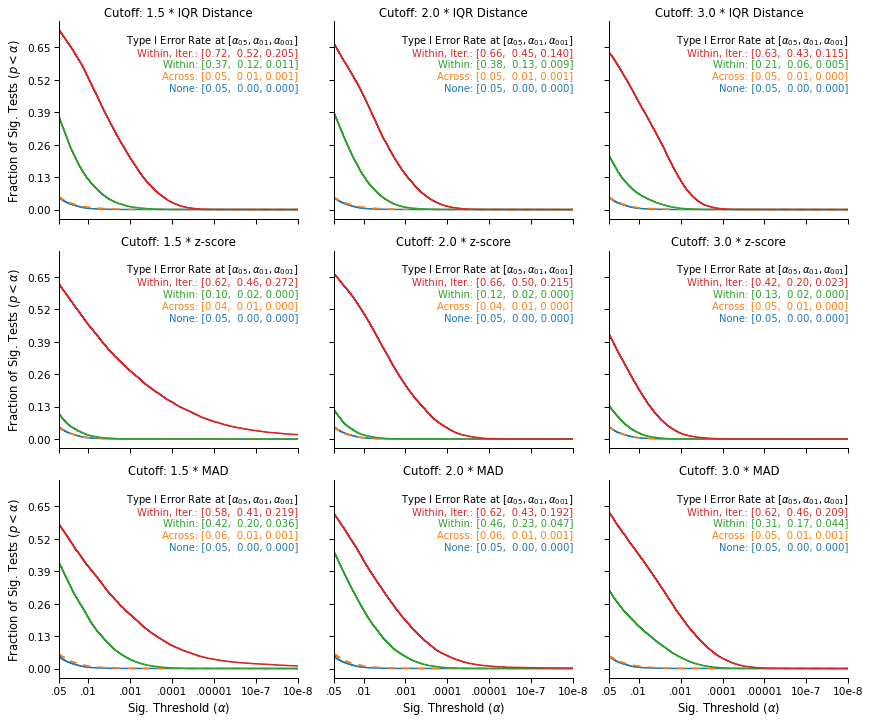

In [14]:
if (
    "df_pvals_ckg_s1" not in locals()
):  # See if the simulations for CKG are loaded in memory
    try:  # If not, see if the simulations have been performed yet.
        df_pvals_ckg_s1 = pd.read_csv("Buffer/Buffered_pvals_ckg_s1.csv")
    except:  # Otherwise perform them.
        df_pvals_ckg_s1 = simulate_exclusion_impact_ckg(
            df2_clean.sort_values("Condition"), 20000, 37
        )
        df_pvals_ckg_s1.to_csv("Buffer/Buffered_pvals_ckg_s1.csv", index=None)

# Plot the simulation results
with sns.plotting_context("paper", font_scale=1.2):
    plot_simulation_results(df_pvals_ckg_s1, include_iterated=True)
    plt.tight_layout()

## Figure 7: Simulate impact of hypothesis-aware (vs. hypothesis-blind) residual exclusions

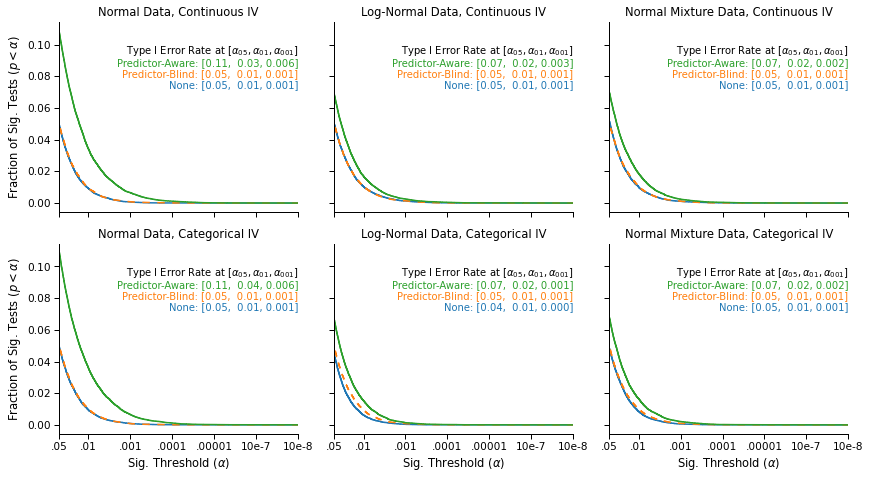

In [15]:
if "df_pvals_resid" not in locals():  # See if the simulations are loaded in memory
    try:  # If not, see if the simulations have been performed yet.
        df_pvals_resid = pd.read_csv("Buffer/Buffered_pvals_resid.csv")
    except:  # Otherwise perform them. Will take a few hours.
        df_pvals_resid = simulate_resid_exclusion_impact(20000)
        df_pvals_resid.to_csv("Buffer/Buffered_pvals_resid.csv", index=None)
with sns.plotting_context("paper", font_scale=1.2):
    # Plot the simulation results
    plot_resids_simulation_results(df_pvals_resid)
    plt.tight_layout()
    plt.savefig("Figures/Fig7.png", dpi=200, bbox_inches="tight")

### Granular description of Type I Error rates (α = .05) when excluding by hypothesis-aware residuals

In [16]:
gb = (
    df_pvals_resid.query("Level == 'Predictor-Aware'")
    .groupby(["N", "DVType", "IVType"], sort=False)
    .mean()
    .iloc[:, 2]
    .unstack(-2)
    .unstack(-1)
    * 100
)
gb.style.format("{:.0f}%")

### Granular description of Type I Error rates (α = .01) when excluding by hypothesis-aware residuals

In [17]:
gb = (
    df_pvals_resid.query("Level == 'Predictor-Aware'")
    .groupby(["N", "DVType", "IVType"], sort=False)
    .mean()
    .iloc[:, 3]
    .unstack(-2)
    .unstack(-1)
    * 100
)
gb.style.format("{:.1f}%")

### Granular description of Type I Error rates (α = .001) when excluding by hypothesis-aware residuals

In [18]:
gb = (
    df_pvals_resid.query("Level == 'Predictor-Aware'")
    .groupby(["N", "DVType", "IVType"], sort=False)
    .mean()
    .iloc[:, 4]
    .unstack(-2)
    .unstack(-1)
    * 1000
)
gb.style.format("{:.1f}‰")

In [19]:
!jupyter nbconvert --to html --no-prompt --no-input Analysis.ipynb

[NbConvertApp] Converting notebook Analysis.ipynb to html
[NbConvertApp] Writing 656990 bytes to Analysis.html
